<a href="https://colab.research.google.com/github/leotamasauskas/Aalise-de-CO/blob/main/Aalise_de_CO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
folder_path = '/content/drive/My Drive/CO2'


In [ ]:
# Caminho dos arquivos CSV
ilha1 = '/content/drive/My Drive/CO2/CO_TimeSeries_Ilha1_Export.csv'
belem = '/content/drive/My Drive/CO2/CO_BELEM_Export.csv'

# Carregar os dados
df_ilha1 = pd.read_csv(ilha1)
df_belem = pd.read_csv(belem)


In [ ]:
# Converter a coluna 'date' para datetime
df_ilha1['date'] = pd.to_datetime(df_ilha1['date'])
df_belem['date'] = pd.to_datetime(df_belem['date'])

# Verificar se as colunas 'CO' e 'date' existem
print(df_ilha1[['date', 'CO']].head())
print(df_belem[['date', 'CO']].head())

# Definir 'date' como índice
df_ilha1.set_index('date', inplace=True)
df_belem.set_index('date', inplace=True)


        date        CO
0 2019-11-22  0.040627
1 2019-11-25       NaN
2 2019-11-25  0.035360
3 2019-11-26  0.032468
4 2019-11-27  0.034422
        date        CO
0 2019-11-22  0.039310
1 2019-11-25       NaN
2 2019-11-25  0.036354
3 2019-11-26  0.033099
4 2019-11-27  0.035552


In [ ]:
# Inicializar o scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Normalizar os dados de CO2
df_ilha1['CO_scaled'] = scaler.fit_transform(df_ilha1[['CO']])
df_belem['CO_scaled'] = scaler.fit_transform(df_belem[['CO']])

# Verificar as primeiras linhas após normalização
print(df_ilha1[['CO', 'CO_scaled']].head())
print(df_belem[['CO', 'CO_scaled']].head())

                  CO  CO_scaled
date                           
2019-11-22  0.040627   0.476700
2019-11-25       NaN        NaN
2019-11-25  0.035360   0.365616
2019-11-26  0.032468   0.304615
2019-11-27  0.034422   0.345822
                  CO  CO_scaled
date                           
2019-11-22  0.039310   0.437117
2019-11-25       NaN        NaN
2019-11-25  0.036354   0.368521
2019-11-26  0.033099   0.292974
2019-11-27  0.035552   0.349899


Média de CO normalizada - Ilha 1: 0.3408
Média de CO normalizada - Belém: 0.3242
Diferença entre as emissões de CO (Belém - Ilha1): -0.0167


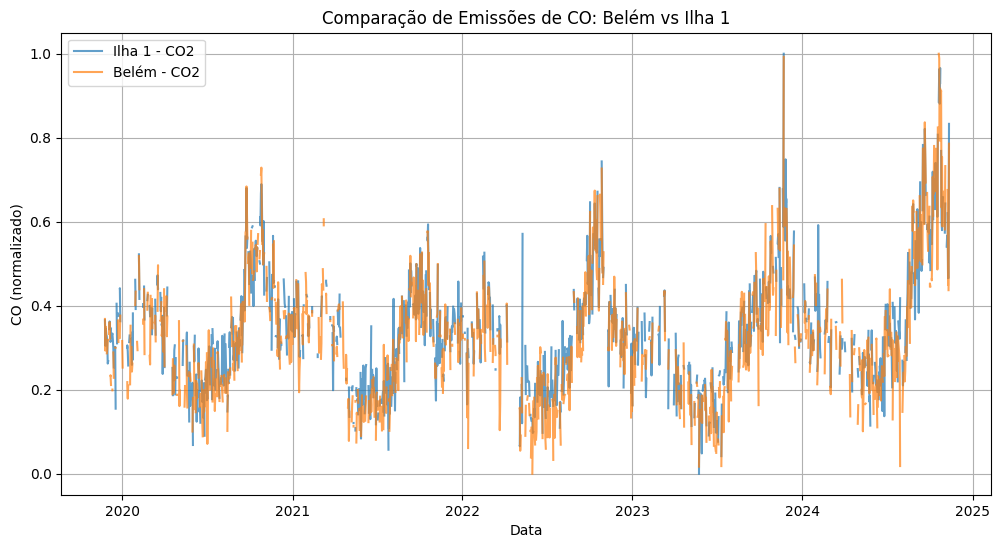

In [ ]:
# Calcular a média do CO2 para cada região
avg_co_ilha1 = df_ilha1['CO_scaled'].mean()
avg_co_belem = df_belem['CO_scaled'].mean()

# Exibir as médias
print(f"Média de CO normalizada - Ilha 1: {avg_co_ilha1:.4f}")
print(f"Média de CO normalizada - Belém: {avg_co_belem:.4f}")

# Calcular a diferença entre as médias de CO2
diff_co2 = avg_co_belem - avg_co_ilha1
print(f"Diferença entre as emissões de CO (Belém - Ilha1): {diff_co2:.4f}")

# Plotar a comparação entre as emissões de CO2 de Belém e Ilha1
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_ilha1.index, df_ilha1['CO_scaled'], label='Ilha 1 - CO2', alpha=0.7)
plt.plot(df_belem.index, df_belem['CO_scaled'], label='Belém - CO2', alpha=0.7)
plt.title('Comparação de Emissões de CO: Belém vs Ilha 1')
plt.xlabel('Data')
plt.ylabel('CO (normalizado)')
plt.legend()
plt.grid(True)
plt.show()
